# Bank Customer Churn Prediction & Retention Analysis

## 1. Project Overview

The objective of this project is to analyze customer behavior and build
machine learning models that predict whether a bank customer is likely
to leave the bank.

## 2. Dataset

The dataset contains information about 10,000 bank customers including
credit score, geography, age, tenure, account balance, number of products,
activity status and estimated salary.

## 3. Objectives

- Analyze customer characteristics associated with churn
- Perform exploratory data analysis
- Build classification models
- Compare model performance
- Identify important factors associated with customer churn
- Provide business recommendations for customer retention

In [12]:
import pandas as pd

file_path = 'Churn_Modelling.csv'
df = pd.read_csv(file_path)

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
df.shape

(10000, 14)

In [15]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [17]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [18]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [21]:
df['Exited'].value_counts(normalize=True) * 100

,proportion
Exited,
0,79.63
1,20.37


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

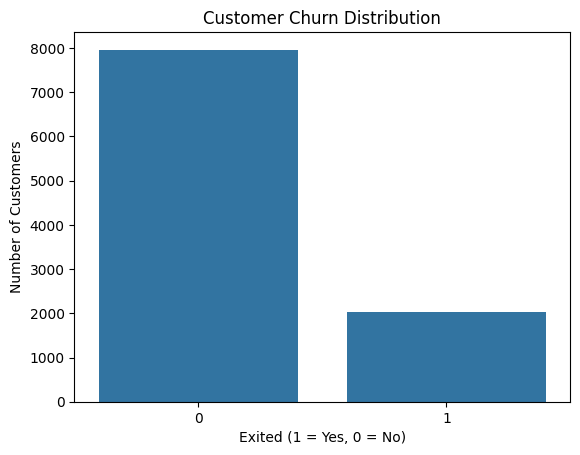

In [23]:
sns.countplot(x='Exited', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Exited (1 = Yes, 0 = No)')
plt.ylabel('Number of Customers')

plt.show()

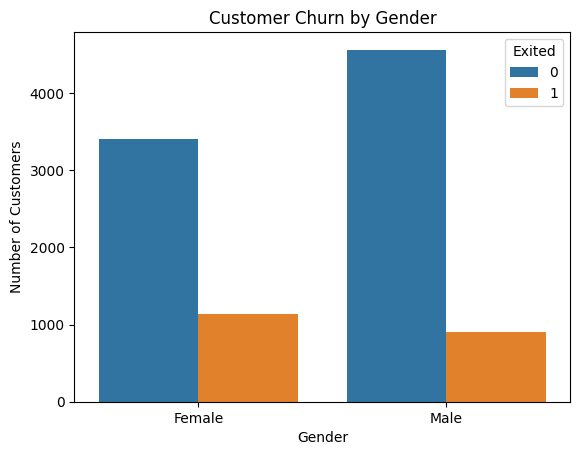

In [24]:
sns.countplot(x='Gender', hue='Exited', data=df)

plt.title('Customer Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

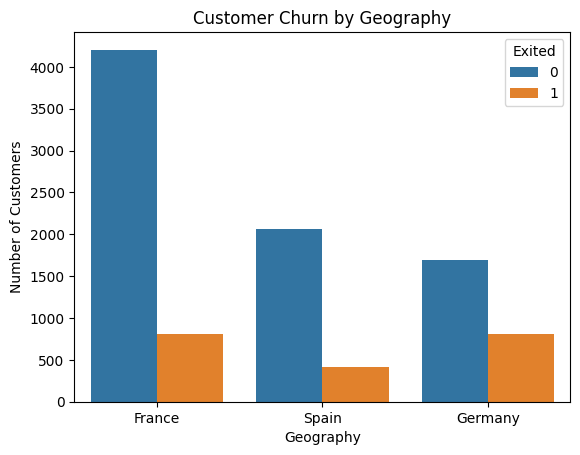

In [25]:
sns.countplot(x='Geography', hue='Exited', data=df)

plt.title('Customer Churn by Geography')
plt.xlabel('Geography')
plt.ylabel('Number of Customers')

plt.show()

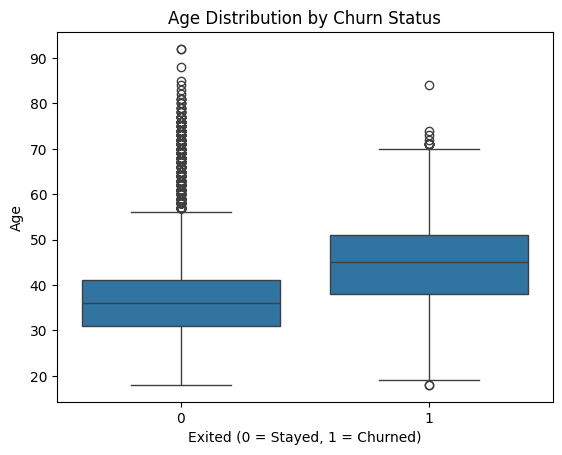

In [26]:
sns.boxplot(x='Exited', y='Age', data=df)

plt.title('Age Distribution by Churn Status')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Age')

plt.show()

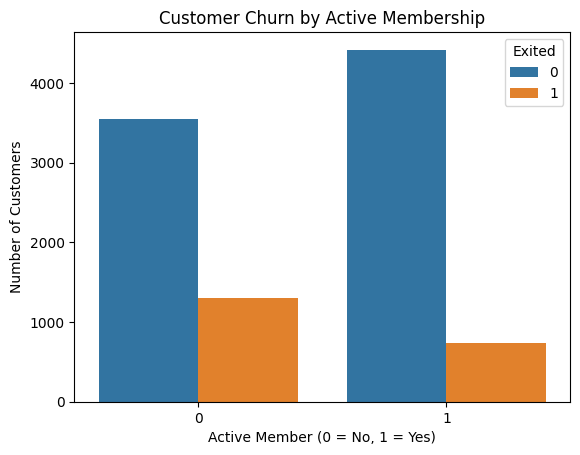

In [27]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)

plt.title('Customer Churn by Active Membership')
plt.xlabel('Active Member (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')

plt.show()

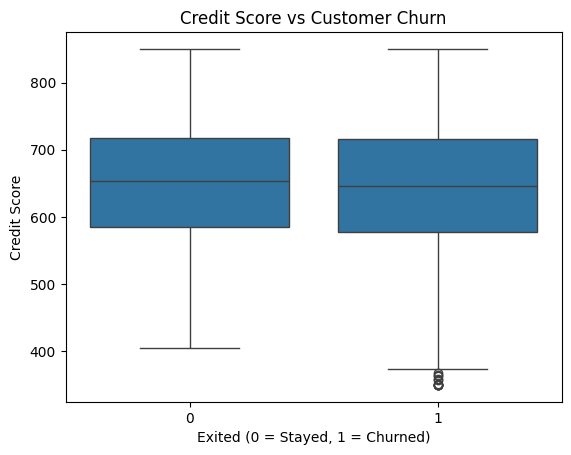

In [28]:
sns.boxplot(x='Exited', y='CreditScore', data=df)

plt.title('Credit Score vs Customer Churn')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Credit Score')

plt.show()

## 4. Data Cleaning & Feature Preparation

Before building machine learning models, the dataset is cleaned and
transformed into a format suitable for machine learning.

In [29]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [30]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [31]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [32]:
df.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


In [33]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [34]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [35]:
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

In [36]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [37]:
X.shape

(10000, 11)

In [38]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 11)
X_test: (2000, 11)
y_train: (8000,)
y_test: (2000,)


In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()


In [44]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
X_train_scaled = scaler.fit_transform(X_train)

In [46]:
X_test_scaled = scaler.transform(X_test)

In [47]:
scaler.fit_transform(X_test)

array([[-0.66718803, -0.27324727,  0.69686459, ..., -0.58042949,
        -0.55809982,  0.93228691],
       [-1.28654133, -0.56367837, -0.34712731, ...,  1.72286214,
        -0.55809982,  0.93228691],
       [-0.95621957,  0.11399421, -0.34712731, ..., -0.58042949,
         1.79179416, -1.07263117],
       ...,
       [-1.37944433,  0.79166679,  1.39285919, ...,  1.72286214,
        -0.55809982, -1.07263117],
       [ 0.4063577 ,  0.01718384,  0.69686459, ..., -0.58042949,
        -0.55809982,  0.93228691],
       [ 1.03603357, -0.56367837, -1.0431219 , ..., -0.58042949,
        -0.55809982,  0.93228691]])

## 5. Machine Learning Model Development

Three classification algorithms are used to predict customer churn:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models are compared using multiple evaluation metrics.

In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:
logistic_model = LogisticRegression(random_state=42)

In [50]:
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [51]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

In [52]:
from sklearn.metrics import accuracy_score

In [53]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.808


In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [55]:
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.808
Precision: 0.5891
Recall   : 0.1867
F1 Score : 0.2836


In [56]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [57]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print(cm_logistic)

[[1540   53]
 [ 331   76]]


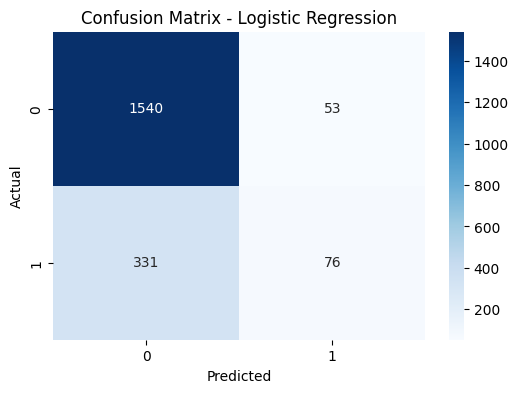

In [58]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 6. Decision Tree Classifier

A Decision Tree is used as a second classification model.
It makes predictions using a sequence of decision rules based on
the input features.

In [59]:
from sklearn.tree import DecisionTreeClassifier

In [60]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

In [61]:
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [62]:
y_pred_tree = decision_tree.predict(X_test)

In [63]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1 Score :", round(tree_f1, 4))

Decision Tree Results
--------------------
Accuracy : 0.856
Precision: 0.7874
Recall   : 0.4005
F1 Score : 0.5309


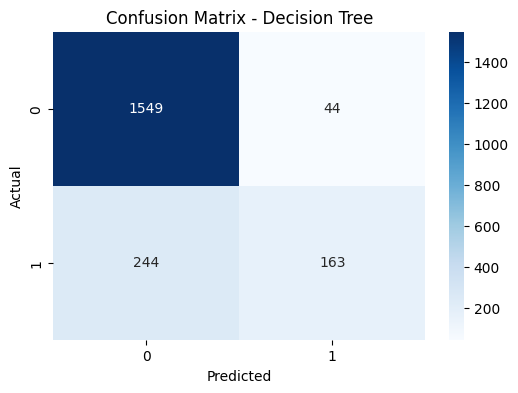

In [64]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 7. Random Forest Classifier

Random Forest combines multiple decision trees to improve predictive
performance and reduce the risk of overfitting associated with a
single decision tree.

In [65]:
from sklearn.ensemble import RandomForestClassifier

In [66]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

In [67]:
random_forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [68]:
y_pred_rf = random_forest.predict(X_test)

In [69]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Results
---------------------
Accuracy : 0.8675
Precision: 0.8198
Recall   : 0.4472
F1 Score : 0.5787


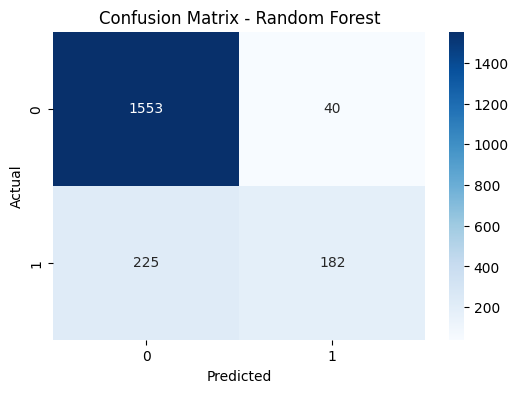

In [70]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 8. Model Performance Comparison

The performance of the three classification models is compared using
accuracy, precision, recall and F1-score.

In [71]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    'Precision': [
        logistic_precision,
        tree_precision,
        rf_precision
    ],
    'Recall': [
        logistic_recall,
        tree_recall,
        rf_recall
    ],
    'F1 Score': [
        logistic_f1,
        tree_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8080,0.589147,0.186732,0.283582
1,Decision Tree,0.8560,0.787440,0.400491,0.530945
2,Random Forest,0.8675,0.819820,0.447174,0.578696


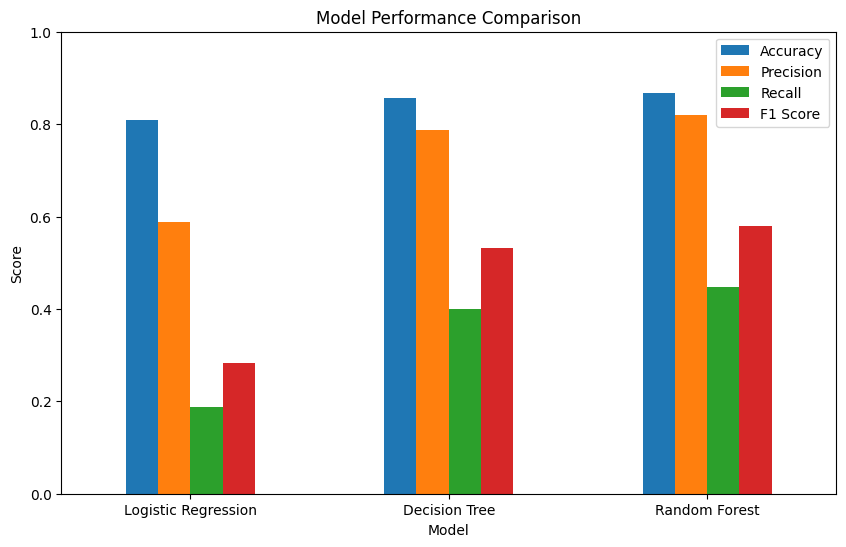

In [72]:
results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend()
plt.show()

## 9. Feature Importance Analysis

Feature importance is analyzed using the Random Forest model to identify
the variables that contribute most to predicting customer churn.

In [73]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
1,Age,0.309933
4,NumOfProducts,0.221854
3,Balance,0.108349
0,CreditScore,0.084370
7,EstimatedSalary,0.083031
6,IsActiveMember,0.065044
8,Geography_Germany,0.047172
2,Tenure,0.042938
10,Gender_Male,0.017621
5,HasCrCard,0.010370


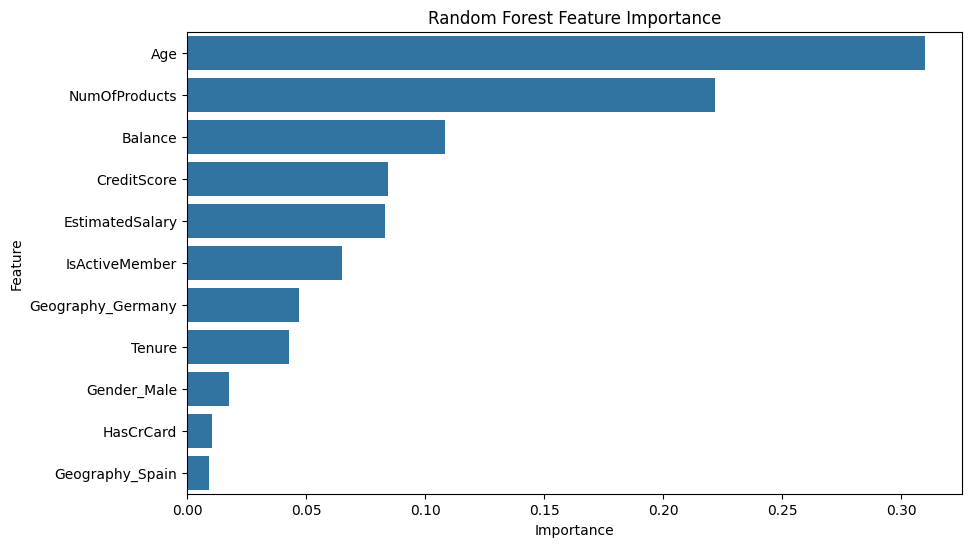

In [74]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [75]:
geography_churn = df.groupby('Geography')['Exited'].mean() * 100

print(geography_churn)

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


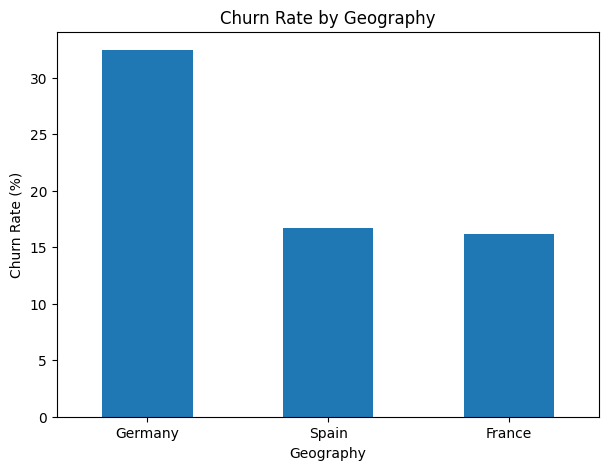

In [76]:
geography_churn.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)
plt.show()

In [77]:
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100

print(active_churn)

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


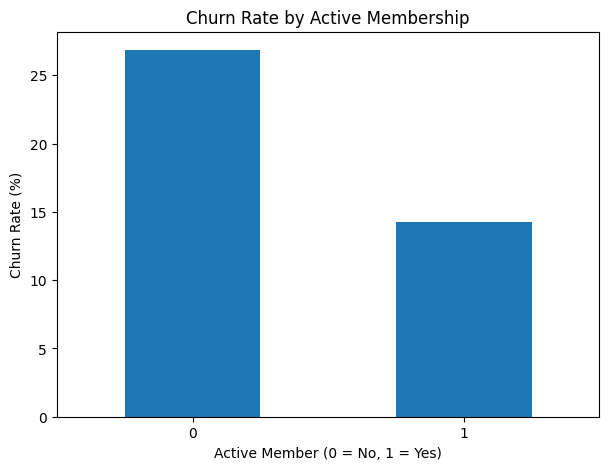

In [78]:
active_churn.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Churn Rate by Active Membership')
plt.xlabel('Active Member (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)
plt.show()

## 10. ROC-AUC Evaluation

ROC-AUC is used to evaluate how well the models distinguish between
customers who churn and customers who do not churn.

In [79]:
from sklearn.metrics import roc_auc_score, roc_curve

# Predicted probabilities
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

# ROC-AUC scores
auc_logistic = roc_auc_score(y_test, y_prob_logistic)
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Logistic Regression ROC-AUC:", round(auc_logistic, 4))
print("Decision Tree ROC-AUC:", round(auc_tree, 4))
print("Random Forest ROC-AUC:", round(auc_rf, 4))

Logistic Regression ROC-AUC: 0.7748
Decision Tree ROC-AUC: 0.8423
Random Forest ROC-AUC: 0.8635


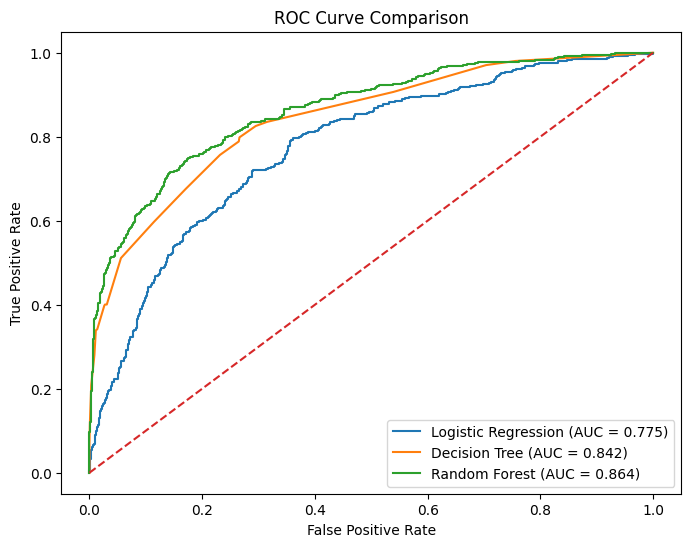

In [80]:
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(fpr_logistic, tpr_logistic, label=f'Logistic Regression (AUC = {auc_logistic:.3f})')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {auc_tree:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [81]:
results['ROC-AUC'] = [
    auc_logistic,
    auc_tree,
    auc_rf
]

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8080,0.589147,0.186732,0.283582,0.774778
1,Decision Tree,0.8560,0.787440,0.400491,0.530945,0.842254
2,Random Forest,0.8675,0.819820,0.447174,0.578696,0.863515


## 11. Customer Churn Prediction

The trained Random Forest model is used to predict the churn probability
of an individual customer.

In [82]:
# Select one customer from the test set
sample_customer = X_test.iloc[[0]]

# Predict churn
prediction = random_forest.predict(sample_customer)[0]

# Predict probability
probability = random_forest.predict_proba(sample_customer)[0][1]

print("Predicted Churn:", "Yes" if prediction == 1 else "No")
print("Churn Probability:", round(probability * 100, 2), "%")

Predicted Churn: No
Churn Probability: 3.38 %


## 12. Business Insights & Customer Retention Analysis

The model results and exploratory analysis are used to identify customer
segments that may require greater attention from the bank.

In [83]:
product_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100

print(product_churn)

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


In [84]:
product_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100

print(product_churn)

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64
